# Computational Gastronomy — Assignment 1 — Question 2

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("data")
OUT_DIR = Path("q2_output")
OUT_DIR.mkdir(exist_ok=True)

BLUE = "#2a78d6"  

# (Recipe ID, Ingredient Name) format for the table
pairs = pd.read_csv(DATA_DIR / "recipe_id_ingredient_name.csv")
print("Loaded", len(pairs), "(recipe_id, ingredient_name) rows covering",
      pairs["recipe_id"].nunique(), "recipes")
pairs.head()

Loaded 97427 (recipe_id, ingredient_name) rows covering 9999 recipes


,recipe_id,ingredient_name
0,1,eggs
1,1,milk
2,1,self-raising flour
3,1,powder
4,1,caster sugar


## Q2(a) — Number of unique ingredients and their frequencies

In [ ]:
ingredient_freq = (
    pairs["ingredient_name"]
    .value_counts()
    .rename_axis("ingredient_name")
    .reset_index(name="frequency")
) # data frame to store the list

n_unique = len(ingredient_freq)
print(f"Number of unique ingredients: {n_unique}")

freq_path = OUT_DIR / "q2a_unique_ingredient_frequencies.csv"
ingredient_freq.to_csv(freq_path, index=False)
print(f"Saved -> {freq_path}")

ingredient_freq.head(15)

Number of unique ingredients: 13226
Saved -> q2_output/q2a_unique_ingredient_frequencies.csv


,ingredient_name,frequency
0,olive oil,2734
1,butter,2046
2,flour,1670
3,eggs,1497
4,garlic,1213
5,onion,1178
6,caster sugar,1103
7,milk,1032
8,golden caster sugar,993
9,garlic clove,917


## Q2(b) — Recipe size distribution

In [ ]:
# Recipe size = number of (extracted) ingredients in that recipe
recipe_sizes = pairs.groupby("recipe_id").size()

s_exact = recipe_sizes.mean()
s = round(s_exact)  #  rounding the average size off to the nearest integer
print(f"Number of recipes: {len(recipe_sizes)}")
print(f"Average recipe size (exact): {s_exact:.4f} ingredients")
print(f"Average recipe size (s, rounded to nearest integer): {s}")
print(recipe_sizes.describe())

Number of recipes: 9999
Average recipe size (exact): 9.7437 ingredients
Average recipe size (s, rounded to nearest integer): 10
count    9999.000000
mean        9.743674
std         4.280989
min         1.000000
25%         7.000000
50%         9.000000
75%        12.000000
max        57.000000
dtype: float64


Saved -> q2_output/q2b_recipe_size_distribution.png


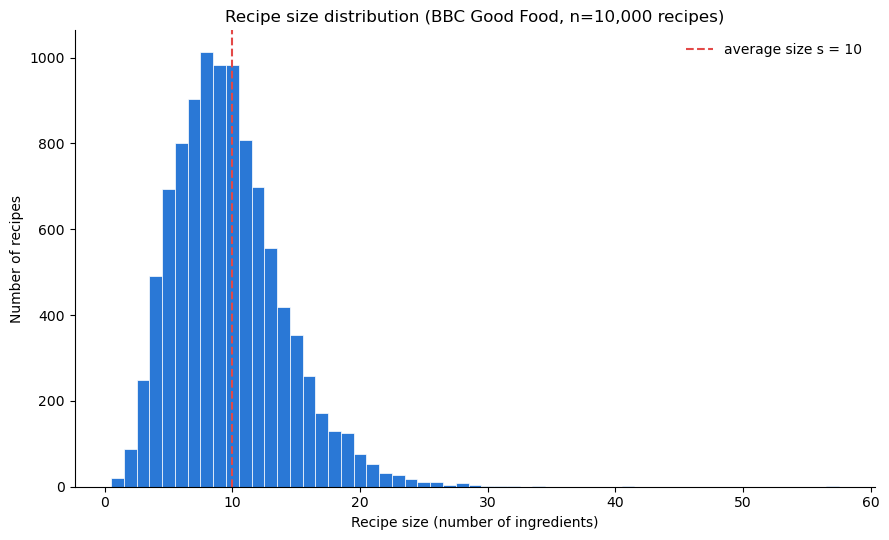

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.5))

bins = np.arange(recipe_sizes.min(), recipe_sizes.max() + 2) - 0.5
ax.hist(recipe_sizes, bins=bins, color=BLUE, edgecolor="white", linewidth=0.5)

ax.axvline(s, color="#e34948", linestyle="--", linewidth=1.5,
            label=f"average size s = {s}")

ax.set_title("Recipe size distribution (BBC Good Food, n=10,000 recipes)")
ax.set_xlabel("Recipe size (number of ingredients)")
ax.set_ylabel("Number of recipes")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

out_path = OUT_DIR / "q2b_recipe_size_distribution.png"
fig.savefig(out_path, dpi=150)
print(f"Saved -> {out_path}")
plt.show()

## Q2(c) — Cumulative distribution of recipe size

Saved -> q2_output/q2c_recipe_size_cumulative_distribution.png


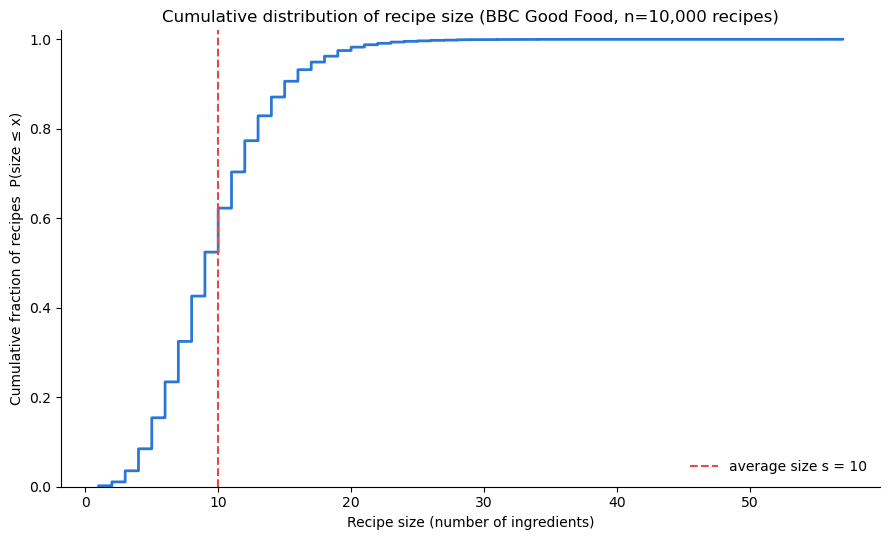

In [5]:
sorted_sizes = np.sort(recipe_sizes.values)
cumulative_fraction = np.arange(1, len(sorted_sizes) + 1) / len(sorted_sizes)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.step(sorted_sizes, cumulative_fraction, where="post", color=BLUE, linewidth=2)

ax.axvline(s, color="#e34948", linestyle="--", linewidth=1.5,
            label=f"average size s = {s}")

ax.set_title("Cumulative distribution of recipe size (BBC Good Food, n=10,000 recipes)")
ax.set_xlabel("Recipe size (number of ingredients)")
ax.set_ylabel("Cumulative fraction of recipes  P(size \u2264 x)")
ax.set_ylim(0, 1.02)
ax.legend(frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

out_path = OUT_DIR / "q2c_recipe_size_cumulative_distribution.png"
fig.savefig(out_path, dpi=150)
print(f"Saved -> {out_path}")
plt.show()